# U.S. Hospital EHR Interoperability Analysis

**In short:** when a hospital's electronic health record (EHR) system cannot share information, doctors repeat tests
and miss allergies, medications and earlier results. Medicare requires hospitals to use certified EHR technology to
share records electronically, send prescriptions electronically, give patients online access to their records and
report to public health (the Promoting Interoperability program). This notebook asks which hospitals fall short, and
why.

Data: CMS hospital data 2019-2024 (about 4,500 general and critical access hospitals a year), the latest Promoting
Interoperability file (reporting year 2024) with each hospital's certified EHR ID, the ONC Certified Health IT Product
List (which turns that ID into the EHR developer), and hospital finances from my
[hospital finance project](https://github.com/Isaac-Agyapong/US_Hospital_Financial_Performance_Analysis).
All numbers come from the PostgreSQL views in `SQL/04_analytics_views.sql` (the same numbers with their SQL are in
`SQL/query_results.md`).

In [1]:
import warnings
from importlib import import_module
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import psycopg
import viz_style as vs

warnings.filterwarnings("ignore")
vs.apply()
pd.set_option("display.float_format", "{:,.1f}".format)
conn = psycopg.connect(import_module("02_load_postgres").CONNINFO)

def q(sql):
    cur = conn.execute(sql)
    df = pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])
    for c in df.columns:
        if df[c].dtype == object and df[c].map(lambda v: v.__class__.__name__ == "Decimal").any():
            df[c] = df[c].astype(float)
    return df

latest = q("SELECT * FROM analytics.mv_hospital_latest")
print(f"{len(latest):,} hospitals in the latest reporting year; {latest.not_met.sum():,} fell short")

4,489 hospitals in the latest reporting year; 574 fell short


## 1. Data quality first

Before any finding, I checked the data the way EHR data-quality research does (completeness, conformance,
plausibility, consistency, linkage). The main problems and how I handled them:

| Problem found | What I did |
|---|---|
| A blank status means two things: "did not meet" for general and critical access hospitals, and "not in the program" for psychiatric, children's, VA and military hospitals (these are never "met") | Kept only the two hospital types the program applies to |
| 585 hospitals have the text "Not Available" typed into the EHR ID field | Treated as "no EHR ID reported" |
| 9 EHR IDs have the wrong format; 24 IDs are not in the government's product list | Kept, labelled "Unknown" |
| 430 hospitals have a different status in the 2024 general file than in the latest dedicated file (different reporting years) | Used the general file for the 2019-2024 trend and the dedicated file for the latest year |
| 532 hospitals are missing from some yearly snapshots (openings, closures, mergers) | Trend uses whatever hospitals each snapshot holds; "stuck behind" uses hospitals present all six years |

## 2. Small rural hospitals fall short twice as often, and the gap is not closing

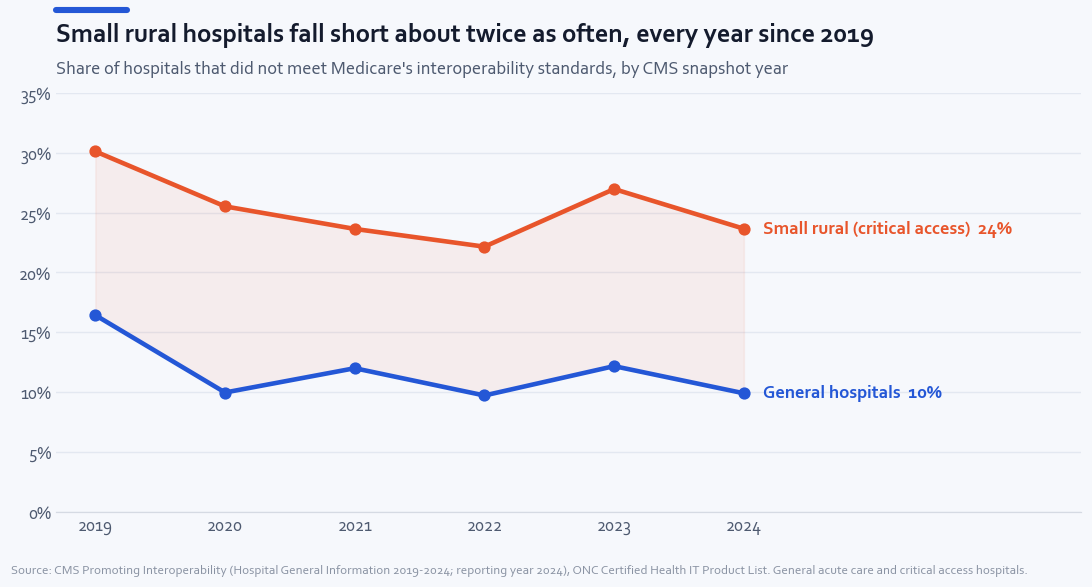

In [2]:
tr = q("SELECT * FROM analytics.v_trend ORDER BY snapshot_year")
w = tr.pivot(index="snapshot_year", columns="hospital_type", values="share_not_met") * 100
fig, ax = plt.subplots(figsize=(10, 5))
for col, colour in (("Critical access", vs.SHORT), ("General acute care", vs.MET)):
    ax.plot(w.index, w[col], color=colour, marker="o", ms=7, lw=3)
    ax.text(2024.15, w[col].iloc[-1], f"{'Small rural (critical access)' if col == 'Critical access' else 'General hospitals'}"
            f"  {w[col].iloc[-1]:.0f}%", color=colour, va="center", fontsize=12, fontweight="bold")
ax.fill_between(w.index, w["General acute care"], w["Critical access"], color=vs.SHORT, alpha=0.07)
ax.set_xlim(2018.7, 2026.6); ax.set_ylim(0, 35); vs.pct(ax); ax.set_xticks(w.index)
vs.title(ax, "Small rural hospitals fall short about twice as often, every year since 2019",
         "Share of hospitals that did not meet Medicare's interoperability standards, by CMS snapshot year")
vs.source(fig); vs.save(fig, "trend_by_type"); fig

## 3. Most hospitals that fall short reported no certified EHR at all

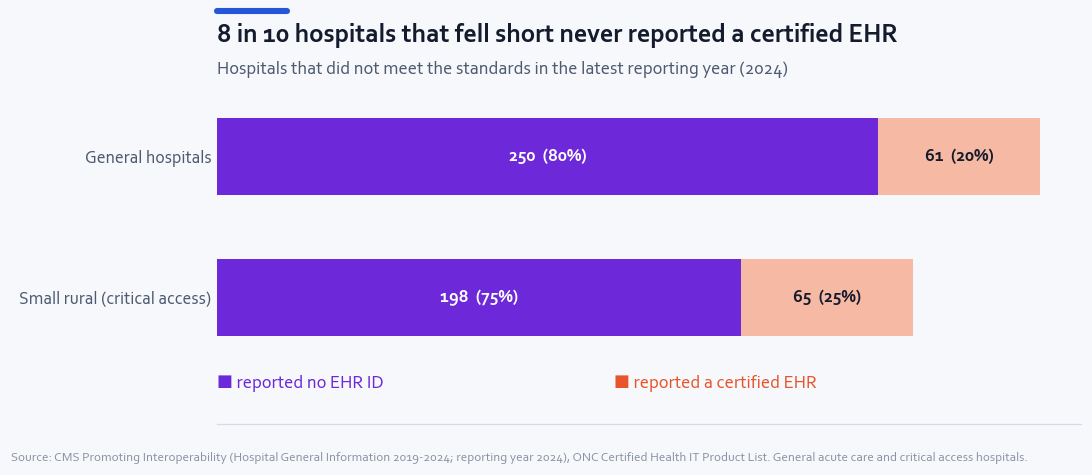

In [3]:
s = latest[latest.not_met].assign(reason=lambda d: np.where(d.reported_ehr_id, "Reported a certified EHR", "Reported no EHR ID"))
c = s.groupby(["hospital_type", "reason"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
names = {"Critical access": "Small rural (critical access)", "General acute care": "General hospitals"}
for i, (t, r) in enumerate(c.iterrows()):
    tot = r.sum(); left = 0
    for reason, colour in (("Reported no EHR ID", vs.NO_EHR), ("Reported a certified EHR", vs.SHORT_L)):
        v = r.get(reason, 0)
        ax.barh(i, v, left=left, color=colour, height=0.55)
        ax.text(left + v / 2, i, f"{v}  ({100 * v / tot:.0f}%)", ha="center", va="center", fontsize=11.5,
                color="white" if reason == "Reported no EHR ID" else vs.INK, fontweight="bold")
        left += v
ax.set_yticks(range(len(c)), [names[t] for t in c.index]); ax.grid(False); ax.set_xticks([])
ax.text(0, -0.55, "■ reported no EHR ID", color=vs.NO_EHR, fontsize=12, va="top")
ax.text(150, -0.55, "■ reported a certified EHR", color=vs.SHORT, fontsize=12, va="top"); ax.set_ylim(-0.9, 1.45)
share_no = (~s.reported_ehr_id).mean()
vs.title(ax, f"{round(10 * share_no)} in 10 hospitals that fell short never reported a certified EHR",
         "Hospitals that did not meet the standards in the latest reporting year (2024)")
vs.source(fig); vs.save(fig, "no_ehr_id"); fig

## 4. The EHR vendor matters, even for the same kind of hospital

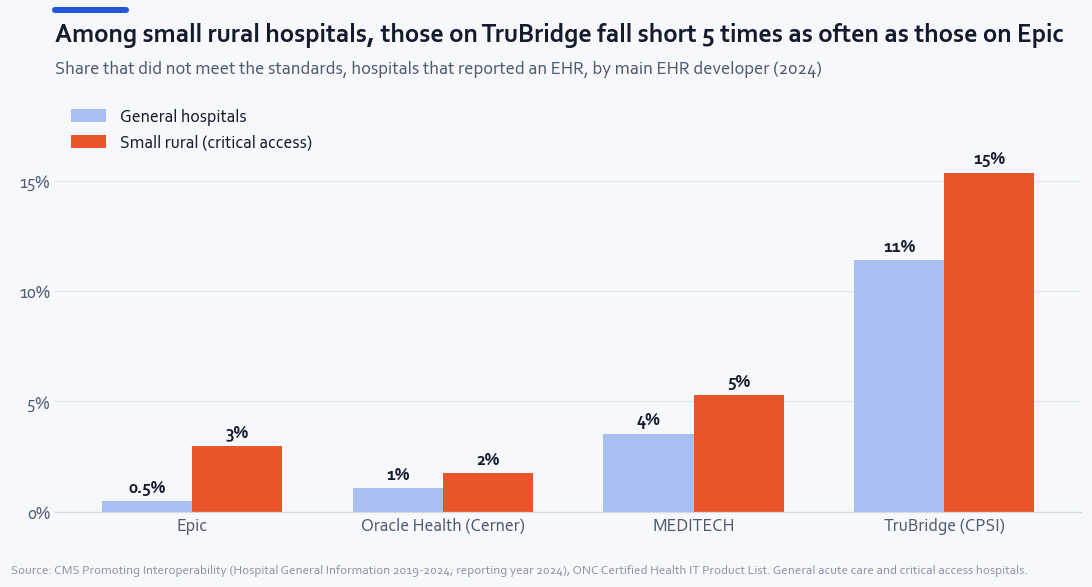

In [4]:
v = latest[latest.reported_ehr_id & latest.ehr_group.isin(["Epic", "Oracle Health (Cerner)", "MEDITECH", "TruBridge (CPSI)"])]
g = v.groupby(["ehr_group", "hospital_type"]).not_met.mean().unstack() * 100
g = g.loc[["Epic", "Oracle Health (Cerner)", "MEDITECH", "TruBridge (CPSI)"]]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(g)); wbar = 0.36
for k, (col, colour) in enumerate((("General acute care", vs.MET_L), ("Critical access", vs.SHORT))):
    b = ax.bar(x + (k - 0.5) * wbar, g[col], wbar, color=colour, label=names[col])
    for xi, val in zip(x + (k - 0.5) * wbar, g[col]):
        ax.text(xi, val + 0.4, f"{val:.1f}%" if val < 1 else f"{val:.0f}%", ha="center", fontsize=11.5, fontweight="bold", color=vs.INK)
ax.set_xticks(x, g.index); ax.set_yticks([0, 5, 10, 15]); vs.pct(ax); ax.set_ylim(0, 19); ax.legend(loc="upper left")
ratio = g.loc["TruBridge (CPSI)", "Critical access"] / g.loc["Epic", "Critical access"]
vs.title(ax, f"Among small rural hospitals, those on TruBridge fall short {ratio:.0f} times as often as those on Epic",
         "Share that did not meet the standards, hospitals that reported an EHR, by main EHR developer (2024)")
vs.source(fig); vs.save(fig, "by_vendor"); fig

In [5]:
q('SELECT * FROM analytics.v_by_group WHERE dimension = \'EHR\' ORDER BY hospitals DESC')

,dimension,grp,hospitals,share_not_met
0,EHR,Epic,1886,0.0
1,EHR,Oracle Health (Cerner),834,0.0
2,EHR,MEDITECH,669,0.0
3,EHR,No EHR ID reported,448,1.0
4,EHR,TruBridge (CPSI),296,0.1
5,EHR,MEDHOST,117,0.0
6,EHR,Altera (Allscripts),112,0.0
7,EHR,Other,74,0.1
8,EHR,Unknown,53,0.2


## 5. Money and size: struggling and small hospitals fall behind

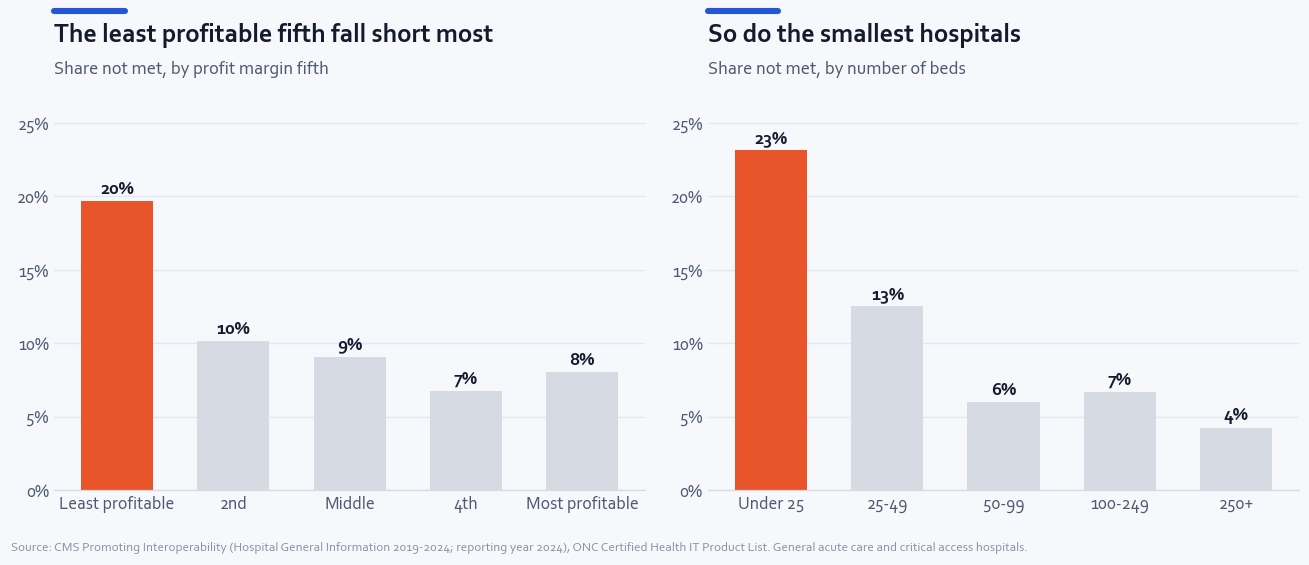

In [6]:
fin = latest.dropna(subset=["total_margin"]).copy()
fin["fifth"] = pd.qcut(fin.total_margin.rank(method="first"), 5, labels=["Least profitable", "2nd", "Middle", "4th", "Most profitable"])
f5 = fin.groupby("fifth", observed=True).not_met.mean() * 100
sz = latest.dropna(subset=["beds"]).assign(size=lambda d: pd.cut(d.beds, [0, 24, 49, 99, 249, 1e6],
        labels=["Under 25", "25-49", "50-99", "100-249", "250+"]))
s5 = sz.groupby("size", observed=True).not_met.mean() * 100
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, ser, hi in ((a1, f5, 0), (a2, s5, 0)):
    cols = [vs.SHORT if i == hi else vs.GREY_L for i in range(len(ser))]
    ax.bar(ser.index.astype(str), ser.values, color=cols, width=0.62)
    for i, val in enumerate(ser.values):
        ax.text(i, val + 0.5, f"{val:.0f}%", ha="center", fontsize=12, fontweight="bold")
    vs.pct(ax); ax.set_ylim(0, 27)
vs.title(a1, "The least profitable fifth fall short most", "Share not met, by profit margin fifth")
vs.title(a2, "So do the smallest hospitals", "Share not met, by number of beds")
vs.source(fig); vs.save(fig, "money_and_size"); fig

## 6. Who owns the hospital

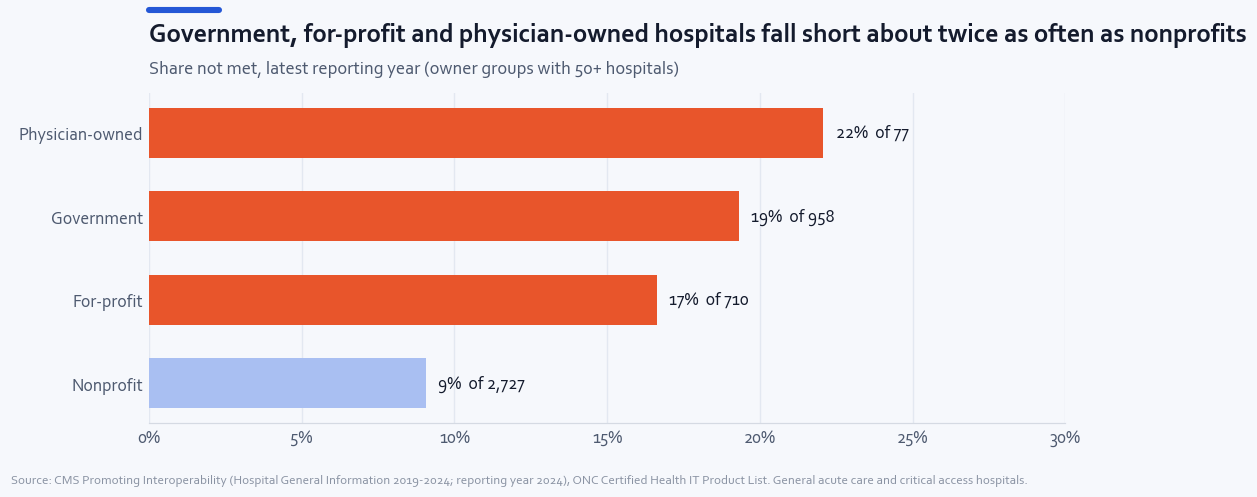

In [7]:
o = latest.groupby("ownership").agg(n=("ccn", "size"), share=("not_met", "mean"))
o = o[o.n >= 50].sort_values("share")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(o.index, 100 * o.share, color=[vs.SHORT if s > o.share.min() * 1.5 else vs.MET_L for s in o.share], height=0.6)
for i, (s, n) in enumerate(zip(o.share, o.n)):
    ax.text(100 * s + 0.4, i, f"{100 * s:.0f}%  of {n:,}", va="center", fontsize=11.5)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); vs.pct(ax, "x"); ax.set_xlim(0, 30)
vs.title(ax, "Government, for-profit and physician-owned hospitals fall short about twice as often as nonprofits",
         "Share not met, latest reporting year (owner groups with 50+ hospitals)")
vs.source(fig); vs.save(fig, "by_owner"); fig

## 7. Where: states with the most hospitals falling short

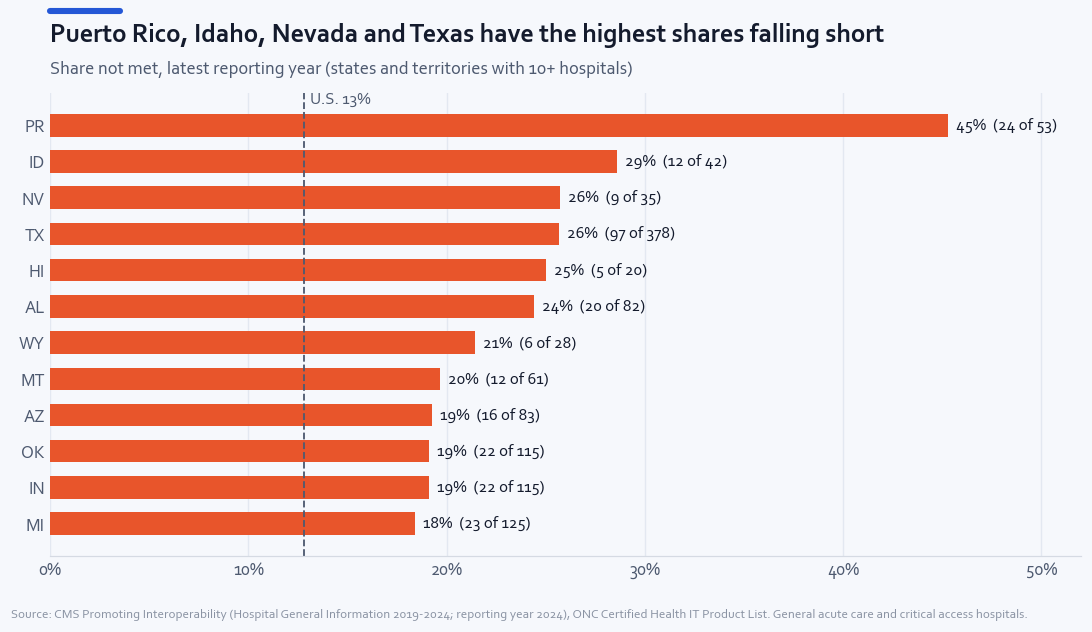

In [8]:
st = q("SELECT * FROM analytics.v_state ORDER BY share_not_met DESC")
top = st.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.barh(top.state, 100 * top.share_not_met, color=vs.SHORT, height=0.62)
for i, (s, n, h) in enumerate(zip(top.share_not_met, top.not_met, top.hospitals)):
    ax.text(100 * s + 0.4, i, f"{100 * s:.0f}%  ({n} of {h})", va="center", fontsize=11)
us = 100 * latest.not_met.mean()
ax.axvline(us, color=vs.INK_2, ls="--", lw=1.2); ax.text(us + 0.3, len(top) - 0.4, f"U.S. {us:.0f}%", color=vs.INK_2, fontsize=11)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); vs.pct(ax, "x"); ax.set_xlim(0, 52)
vs.title(ax, "Puerto Rico, Idaho, Nevada and Texas have the highest shares falling short",
         "Share not met, latest reporting year (states and territories with 10+ hospitals)")
vs.source(fig); vs.save(fig, "by_state"); fig

## 8. A few hospitals are stuck behind year after year

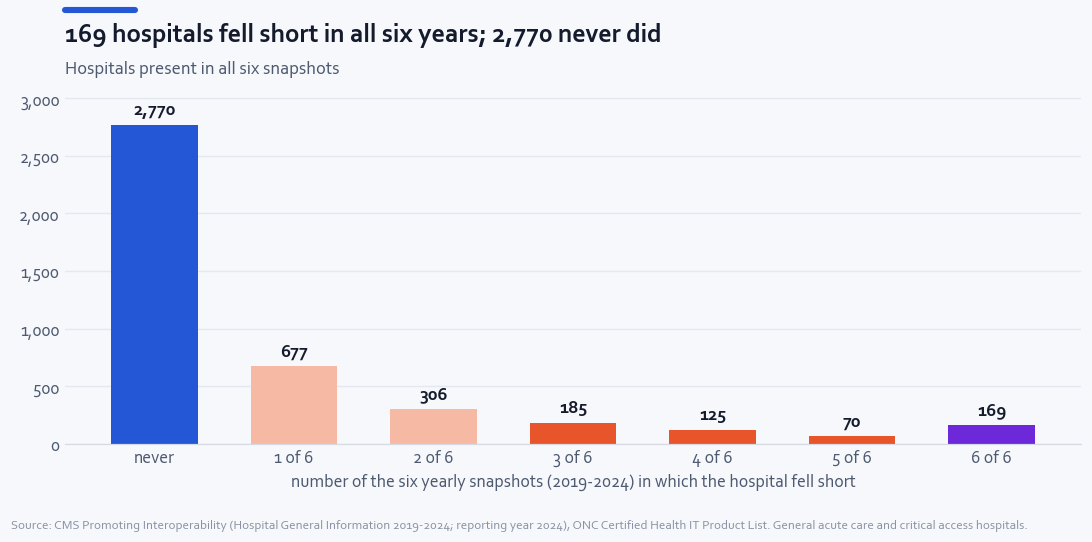

In [9]:
k = latest[latest.years_reported == 6].years_not_met.astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4.6))
cols = [vs.MET] + [vs.SHORT_L] * 2 + [vs.SHORT] * 3 + [vs.NO_EHR]
ax.bar([("never" if i == 0 else f"{i} of 6") for i in k.index], k.values, color=cols[:len(k)], width=0.62)
for i, val in enumerate(k.values):
    ax.annotate(f"{val:,}", (i, val), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
                fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}")); ax.set_ylim(0, k.max() * 1.1)
ax.set_xlabel("number of the six yearly snapshots (2019-2024) in which the hospital fell short")
vs.title(ax, f"{k.get(6, 0)} hospitals fell short in all six years; {k.get(0, 0):,} never did",
         "Hospitals present in all six snapshots")
vs.source(fig); vs.save(fig, "stuck_behind"); fig

## 9. Three EHR developers serve 85% of hospitals

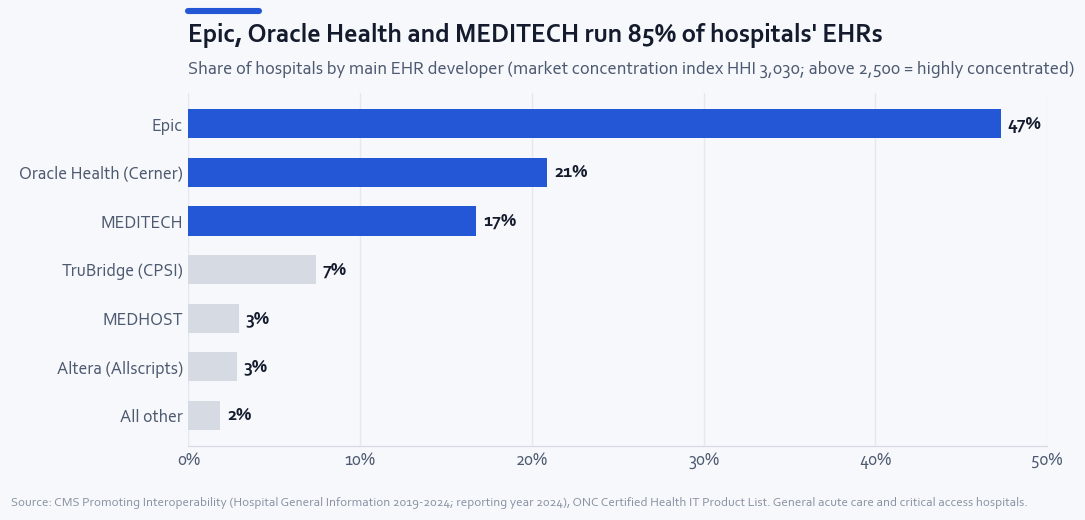

In [10]:
m = latest[latest.main_developer.notna()].main_developer.value_counts()
share = 100 * m / m.sum()
top3 = share.head(3).sum(); hhi = ((share) ** 2).sum()
fig, ax = plt.subplots(figsize=(10, 4.4))
lab = list(share.head(6).index) + ["All other"]
val = list(share.head(6).values) + [share.iloc[6:].sum()]
ax.barh(lab[::-1], val[::-1], color=[vs.MET if i < 3 else vs.GREY_L for i in range(len(lab))][::-1], height=0.6)
for i, x in enumerate(val[::-1]):
    ax.text(x + 0.4, i, f"{x:.0f}%", va="center", fontsize=12, fontweight="bold")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); vs.pct(ax, "x"); ax.set_xlim(0, 50)
vs.title(ax, f"Epic, Oracle Health and MEDITECH run {top3:.0f}% of hospitals' EHRs",
         f"Share of hospitals by main EHR developer (market concentration index HHI {hhi:,.0f}; above 2,500 = highly concentrated)")
vs.source(fig); vs.save(fig, "market_share"); fig

## Summary

1. About **1 in 7** program hospitals (about 620) fell short of Medicare's interoperability standards in the latest
   reporting year. Small rural hospitals fell short about **twice as often** as general hospitals in every year
   since 2019.
2. **About 8 in 10** of those that fell short reported no certified EHR at all: the first problem is taking part,
   not the technology.
3. Among hospitals that did report an EHR, the vendor still matters: hospitals on TruBridge (CPSI) fell short
   about 5 times as often as hospitals on Epic, even within the same hospital type.
4. Hospitals that lost money, small hospitals and government, for-profit and physician-owned hospitals fall short
   more often.
5. Three EHR developers serve 85% of hospitals, a highly concentrated market.

These are associations, not proof of cause. The companion machine learning project tests which of these factors
best predict which hospitals will fall short next.